In [14]:
import numpy as np
import matplotlib.pyplot as plt

In [15]:
# Moderne, aber wissenschaftlich saubere Einstellungen
plt.rcParams.update({
    # Moderne, saubere Schrift (ohne Schnörkel)
    "font.family": "sans-serif",
    "font.size": 11,
    "axes.labelsize": 12,
    "axes.titlesize": 13,
    "legend.fontsize": 11,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    
    # Ticks zeigen nach außen und nur unten/links (viel offener)
    "xtick.direction": "out",
    "ytick.direction": "out",
    "xtick.top": False,
    "ytick.right": False,
    
    # Dezentes Gitter
    "axes.grid": True,
    "grid.color": "#7F8C8D",
    "grid.linestyle": ":",        # Gepunktet statt gestrichelt wirkt feiner
    "grid.alpha": 0.5,
    
    # Legende ohne Rahmen
    "legend.frameon": True,
    
    # Hohe Auflösung
    "figure.dpi": 300,
    "savefig.dpi": 300,
    "savefig.bbox": "tight"
})

Parameter:
  lambda      = 1064.0 nm
  M²          = 1.30
  lambda_eff  = 1383.2 nm
  MFD         = 5.40 um
  wf          = 2.70 um
  f           = 36.60 mm
  zR (Faser)  = 0.0166 mm

Bei Delta = 0 mm:
  Strahlradius an Linse      = 5.9683 mm
  Strahldurchmesser an Linse = 11.9367 mm
  Neue Waist-Position        = 3.6600e-02 m
  Neuer Waist-Radius         = 5968.3245 um
  Neuer Waist-Durchmesser    = 11936.6490 um
  Divergenz (Halbwinkel)     = 0.0738 mrad

Strahlgröße hinter der Linse bei Delta = 0 mm:
  Radius    bei 1 km   = 0.0740 m
  Durchmesser bei 1 km = 0.1480 m
  Radius    bei 500 km = 36.8852 m
  Durchmesser bei 500 km = 73.7705 m


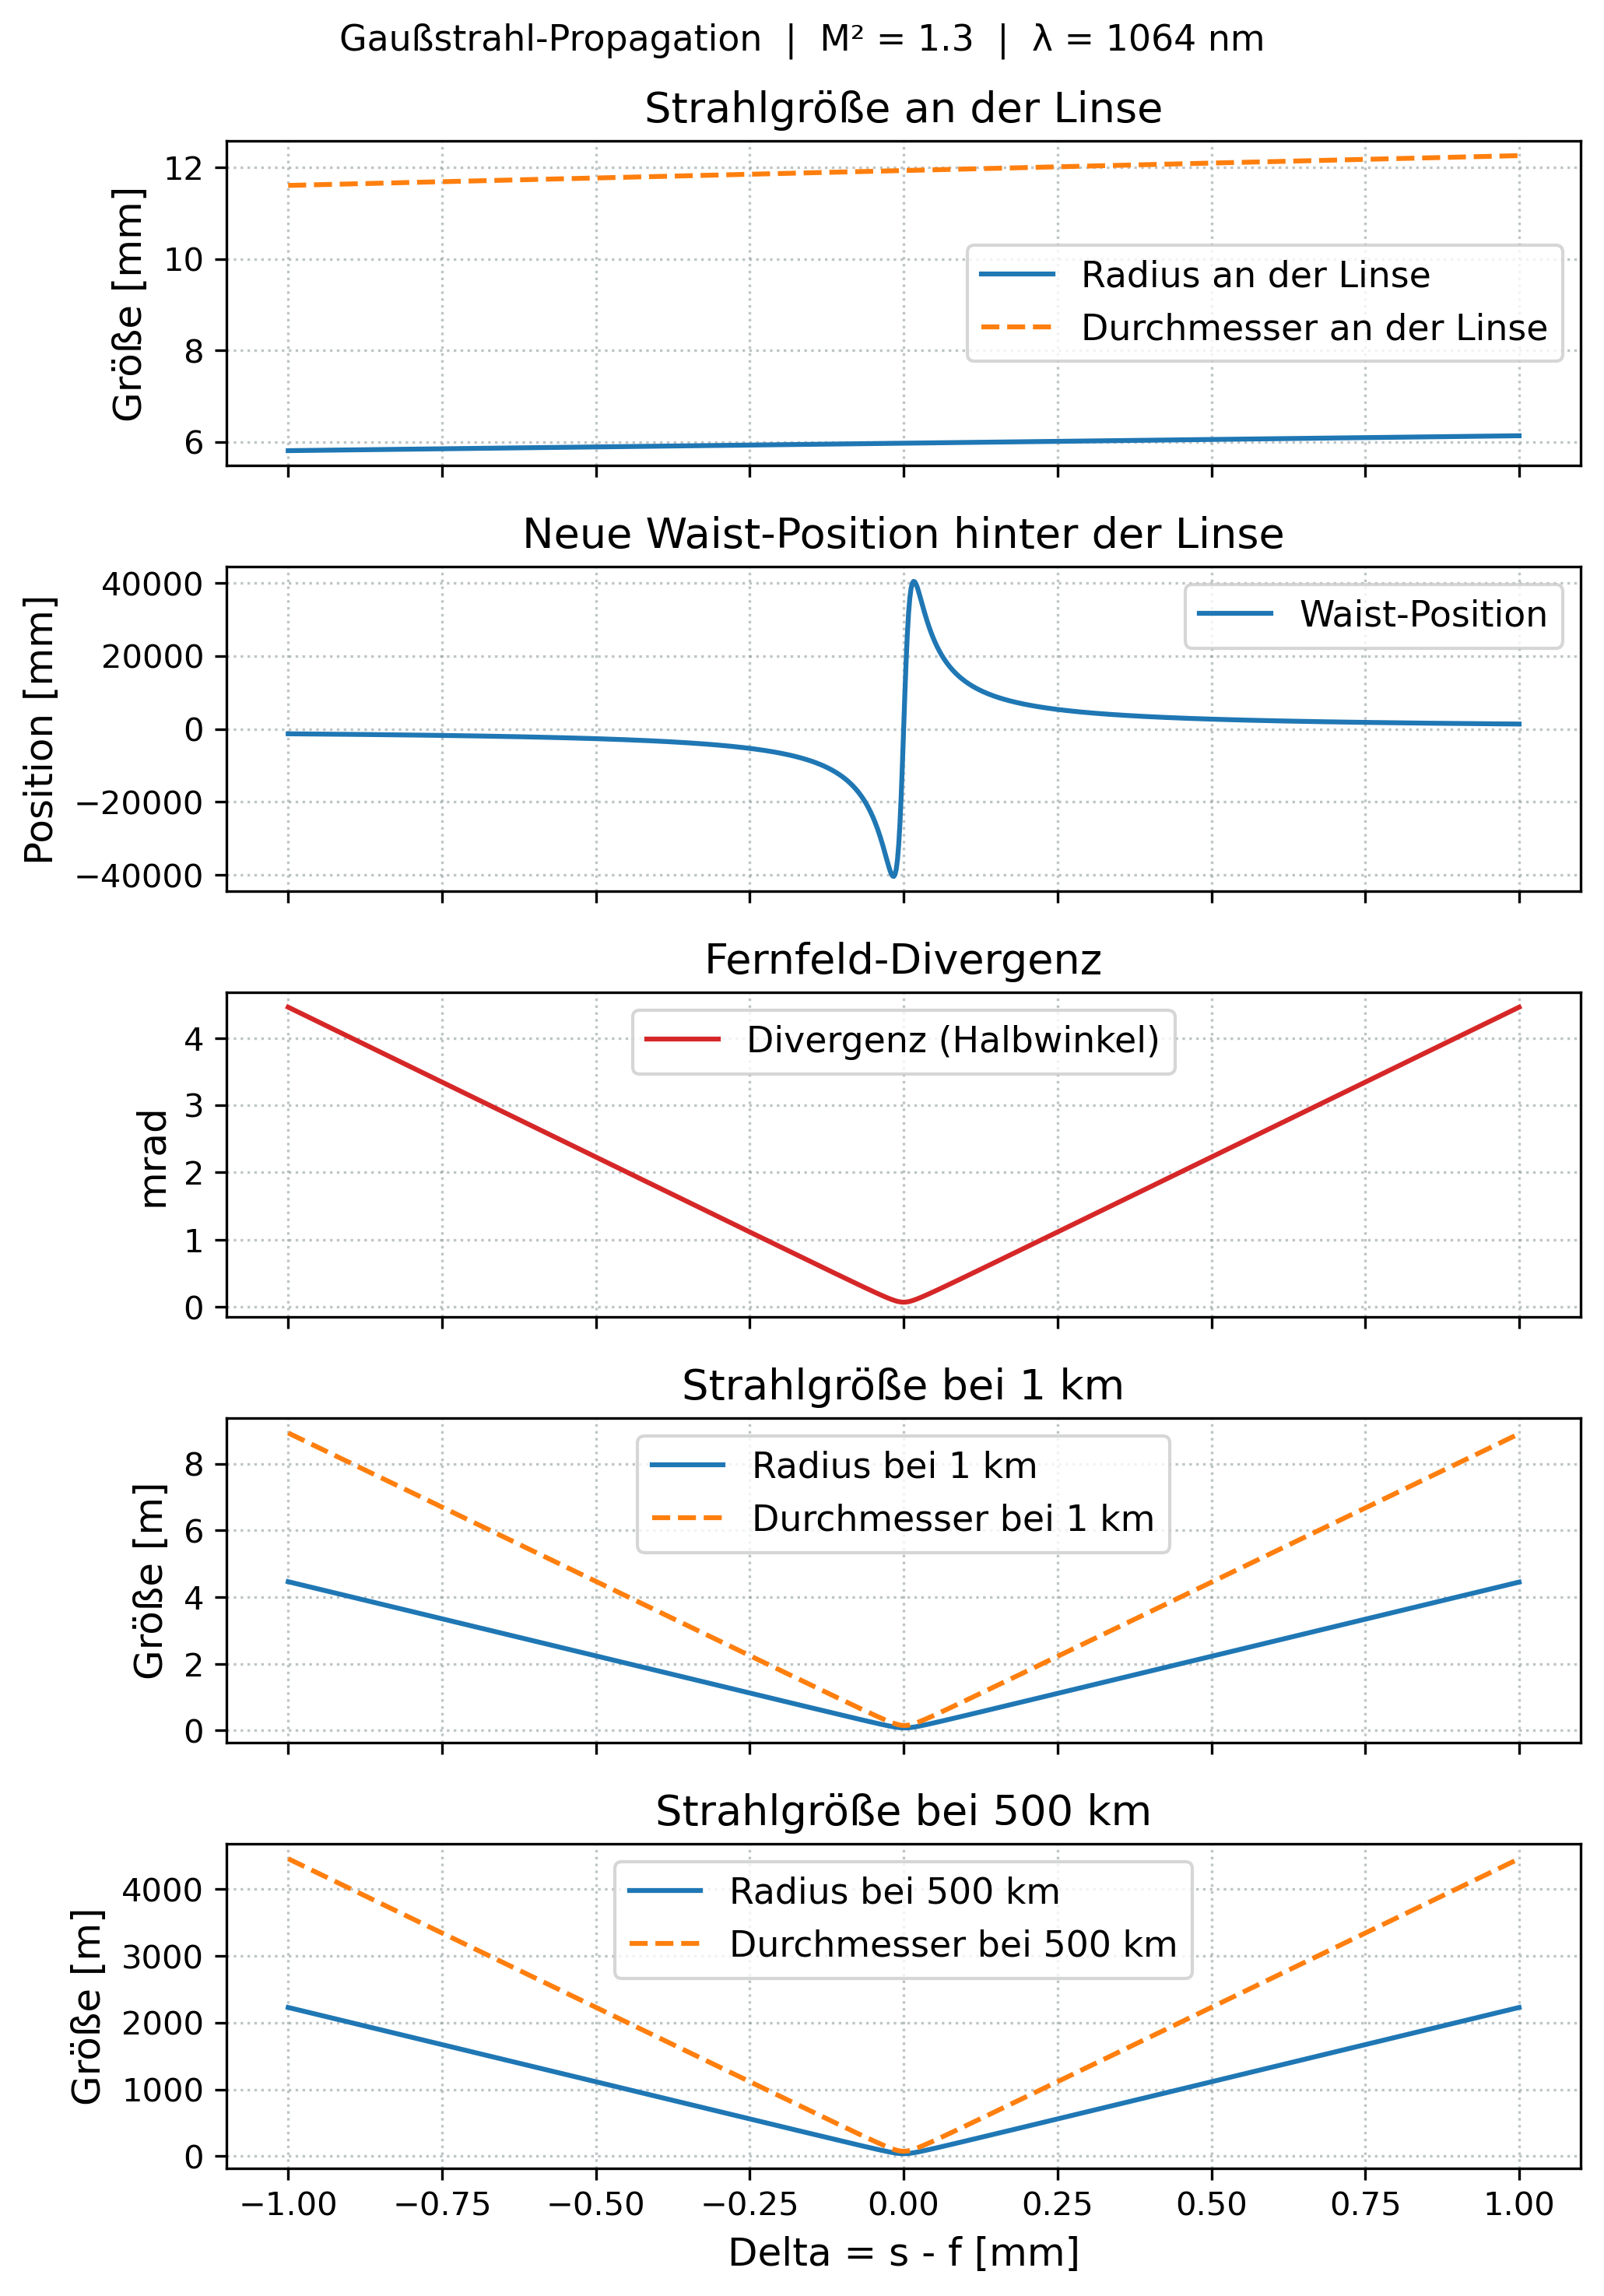

In [20]:
lam  = 1064e-9   # Wellenlänge [m]
M2   = 1.3       # Strahlqualitätsfaktor (1.0 = idealer Gaußstrahl)
MFD  = 5.4e-6    # Mode Field Diameter [m]
wf   = MFD / 2   # Waist-Radius am Faserende [m]
f    = 36.6e-3   # Brennweite [m]

# Effektive Wellenlänge für M²-Strahl
lam_eff = M2 * lam   # [m]  

# Rayleigh-Länge am Faserwaist (mit M²)
zR = np.pi * wf**2 / lam_eff   # [m]

# Delta-Bereich: +/- 1 mm
delta = np.linspace(-1e-3, 1e-3, 1001)
s = f + delta   # Abstand Faser -> Linse [m]

# -----------------------------
# Strahlradius an der Linse
# -----------------------------
w_lens = wf * np.sqrt(1 + (s / zR)**2)
d_lens = 2 * w_lens

# -----------------------------
# q-Parameter vor und nach der Linse
# (ABCD-Transformation unverändert)
# -----------------------------
q1 = s + 1j * zR
q2 = 1 / (1 / q1 - 1 / f)

z_waist = -np.real(q2)   # Neue Waist-Position [m]
zR_new  =  np.imag(q2)   # Neue Rayleigh-Länge  [m]

# Neuer Waist-Radius (mit M²)
w0_new = np.sqrt(lam_eff * zR_new / np.pi)   # 
d0_new = 2 * w0_new

# Divergenz (Halbwinkel, mit M²)
theta      = lam_eff / (np.pi * w0_new)   # [rad]  
theta_mrad = theta * 1e3                  # [mrad]

# -----------------------------
# Strahlgröße bei gegebenen Distanzen
# -----------------------------
z1 = 1e3      # 1 km  [m]
z2 = 500e3    # 500 km [m]

w_1km   = w0_new * np.sqrt(1 + ((z1 - z_waist) / zR_new)**2)
d_1km   = 2 * w_1km

w_500km = w0_new * np.sqrt(1 + ((z2 - z_waist) / zR_new)**2)
d_500km = 2 * w_500km

# -----------------------------
# Ausgabe bei Delta = 0
# -----------------------------
idx0 = np.argmin(np.abs(delta))

print("Parameter:")
print(f"  lambda      = {lam*1e9:.1f} nm")
print(f"  M²          = {M2:.2f}")
print(f"  lambda_eff  = {lam_eff*1e9:.1f} nm")
print(f"  MFD         = {MFD*1e6:.2f} um")
print(f"  wf          = {wf*1e6:.2f} um")
print(f"  f           = {f*1e3:.2f} mm")
print(f"  zR (Faser)  = {zR*1e3:.4f} mm")
print()
print("Bei Delta = 0 mm:")
print(f"  Strahlradius an Linse      = {w_lens[idx0]*1e3:.4f} mm")
print(f"  Strahldurchmesser an Linse = {d_lens[idx0]*1e3:.4f} mm")
print(f"  Neue Waist-Position        = {z_waist[idx0]:.4e} m")
print(f"  Neuer Waist-Radius         = {w0_new[idx0]*1e6:.4f} um")
print(f"  Neuer Waist-Durchmesser    = {d0_new[idx0]*1e6:.4f} um")
print(f"  Divergenz (Halbwinkel)     = {theta_mrad[idx0]:.4f} mrad")
print()
print("Strahlgröße hinter der Linse bei Delta = 0 mm:")
print(f"  Radius    bei 1 km   = {w_1km[idx0]:.4f} m")
print(f"  Durchmesser bei 1 km = {d_1km[idx0]:.4f} m")
print(f"  Radius    bei 500 km = {w_500km[idx0]:.4f} m")
print(f"  Durchmesser bei 500 km = {d_500km[idx0]:.4f} m")

# -----------------------------
# Plot
# -----------------------------
fig, ax = plt.subplots(5, 1, figsize=(7, 10), sharex=True)
fig.suptitle(f"Gaußstrahl-Propagation  |  M² = {M2}  |  λ = {lam*1e9:.0f} nm",
             fontsize=11)

ax[0].plot(delta*1e3, w_lens*1e3, label="Radius an der Linse")
ax[0].plot(delta*1e3, d_lens*1e3, "--", label="Durchmesser an der Linse")
ax[0].set_ylabel("Größe [mm]")
ax[0].set_title("Strahlgröße an der Linse")
ax[0].grid(True); ax[0].legend()

ax[1].plot(delta*1e3, z_waist*1e3, label="Waist-Position")
ax[1].set_ylabel("Position [mm]")
ax[1].set_title("Neue Waist-Position hinter der Linse")
ax[1].grid(True); ax[1].legend()

ax[2].plot(delta*1e3, theta_mrad, color="tab:red", label="Divergenz (Halbwinkel)")
ax[2].set_ylabel("mrad")
ax[2].set_title("Fernfeld-Divergenz")
ax[2].grid(True); ax[2].legend()

ax[3].plot(delta*1e3, w_1km, label="Radius bei 1 km")
ax[3].plot(delta*1e3, d_1km, "--", label="Durchmesser bei 1 km")
ax[3].set_ylabel("Größe [m]")
ax[3].set_title("Strahlgröße bei 1 km")
ax[3].grid(True); ax[3].legend()

ax[4].plot(delta*1e3, w_500km, label="Radius bei 500 km")
ax[4].plot(delta*1e3, d_500km, "--", label="Durchmesser bei 500 km")
ax[4].set_xlabel("Delta = s - f [mm]")
ax[4].set_ylabel("Größe [m]")
ax[4].set_title("Strahlgröße bei 500 km")
ax[4].grid(True); ax[4].legend()

plt.tight_layout()
plt.show()

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


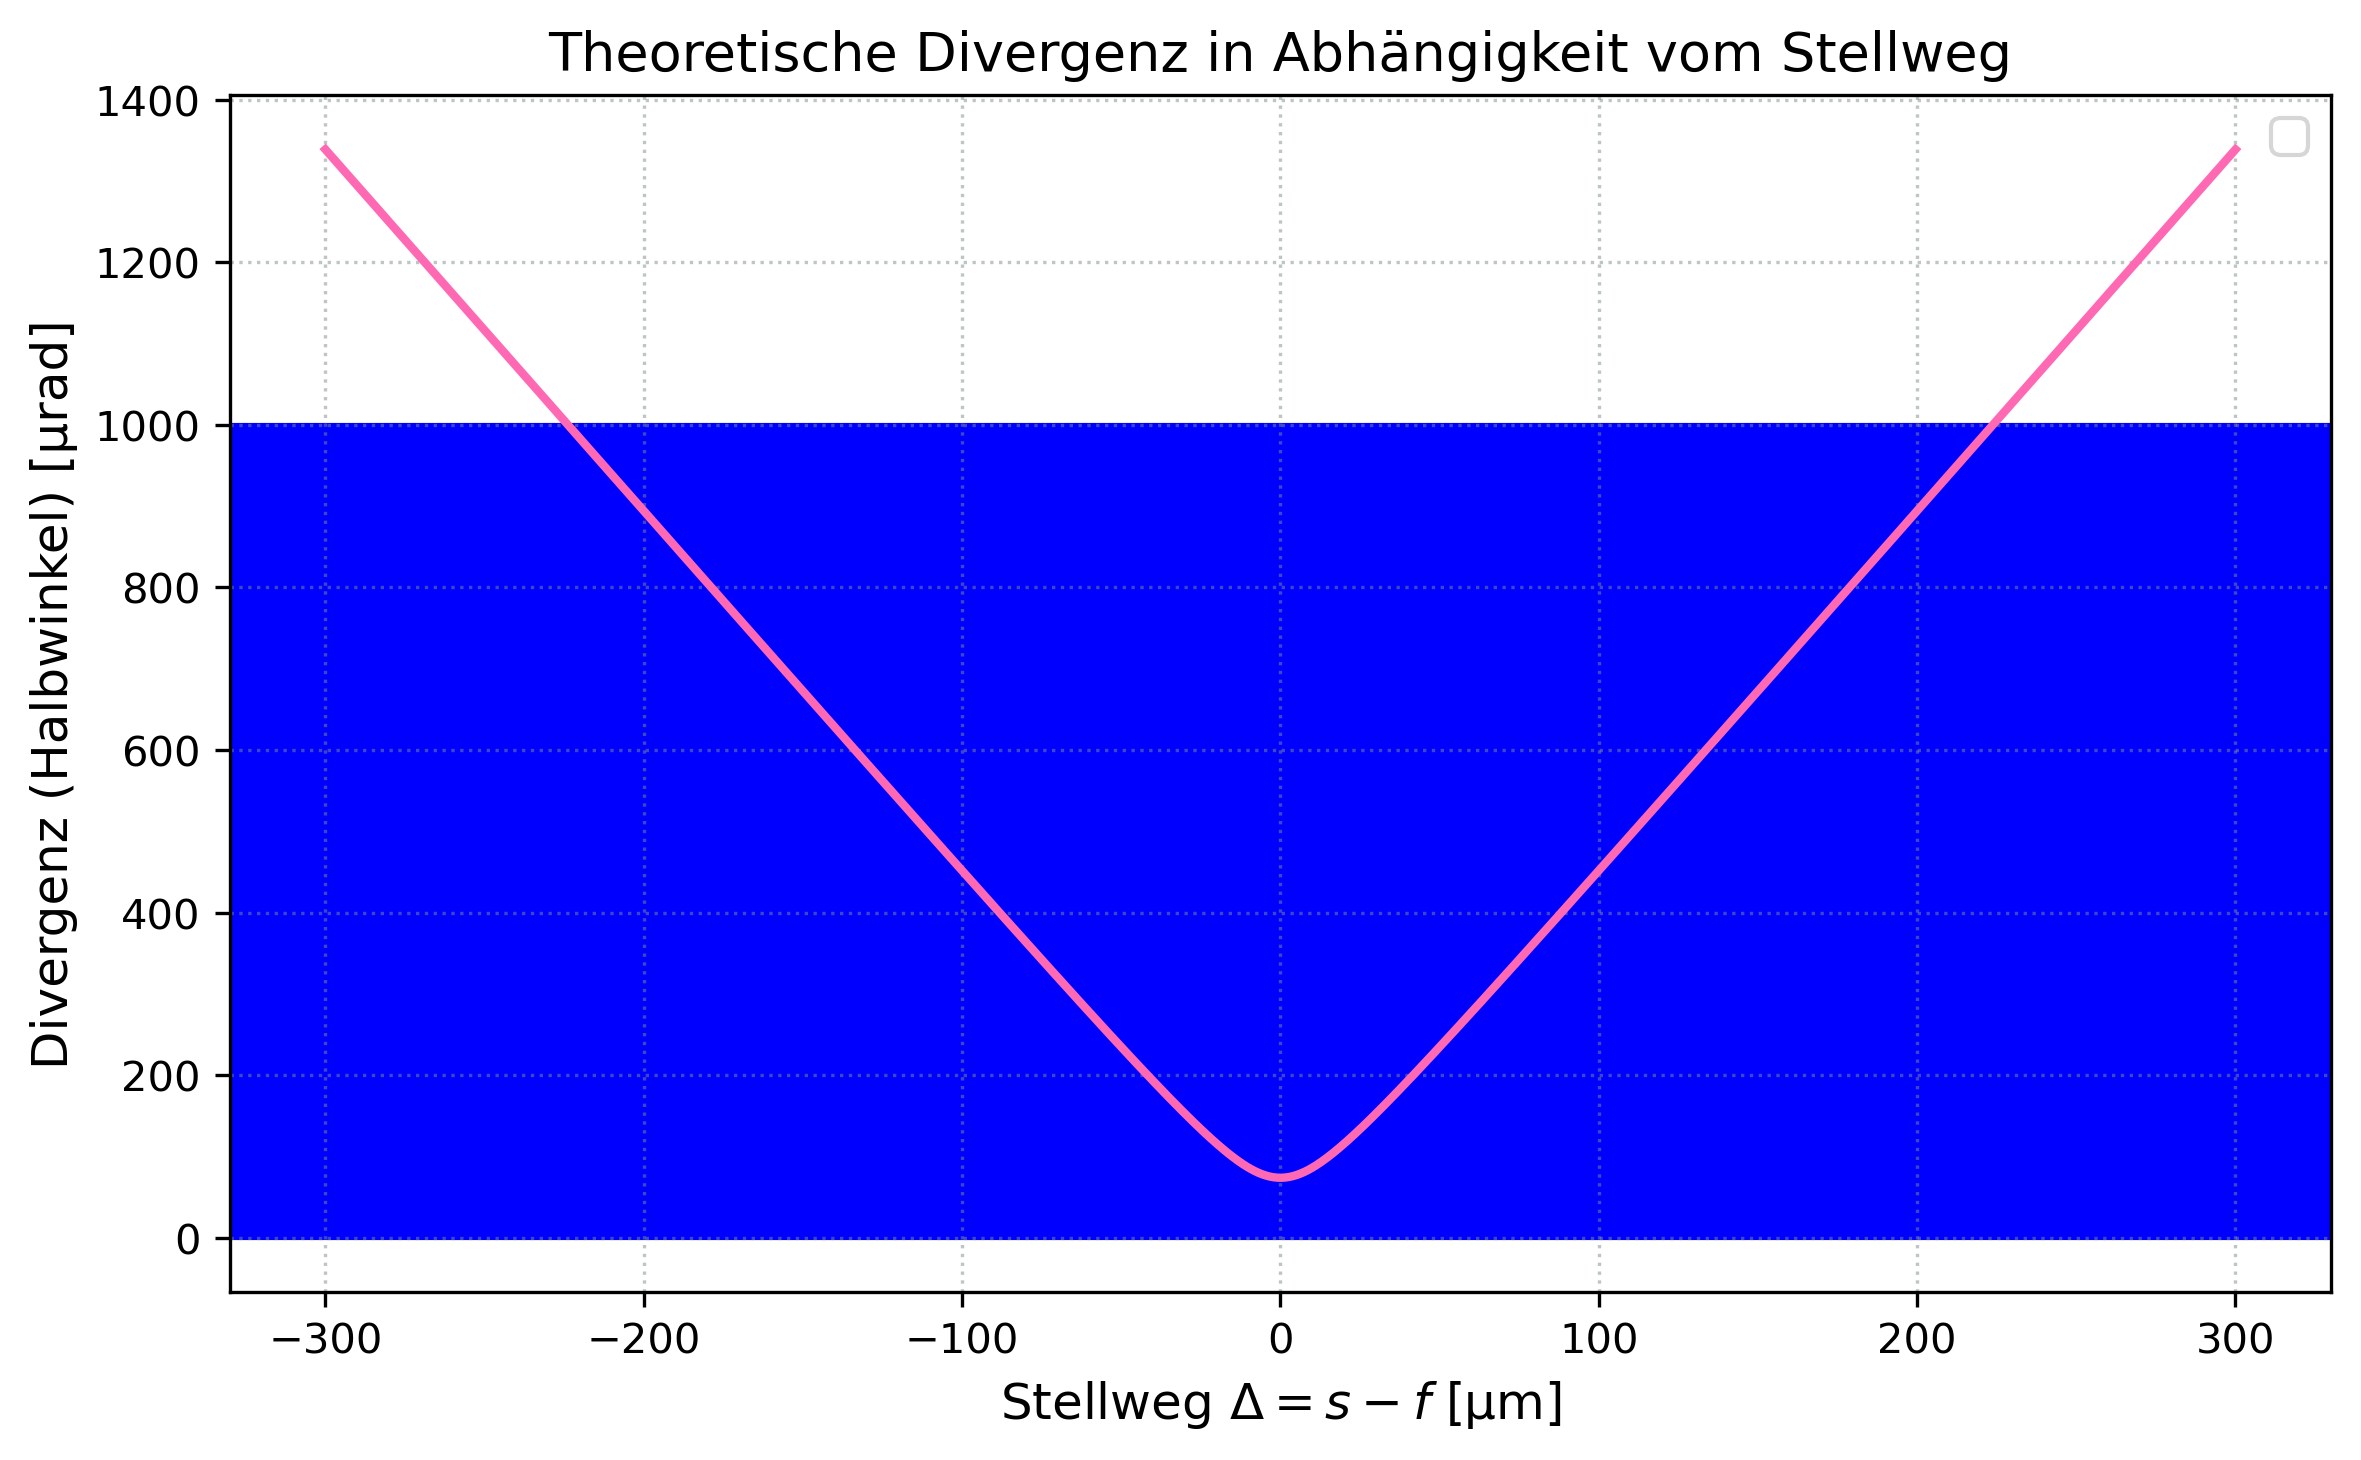

In [17]:
lam  = 1064e-9   # Wellenlänge [m]
M2   = 1.3       # Strahlqualitätsfaktor
MFD  = 5.4e-6    # Mode Field Diameter [m]
wf   = MFD / 2   # Waist-Radius am Faserende [m]
f    = 36.6e-3   # Brennweite [m]

lam_eff = M2 * lam  

# Das ist dein Stellweg um den perfekten Fokuspunkt (Delta)
delta = np.linspace(-300*1e-6, 300*1e-6, 1000)
zR = np.pi * wf**2 / lam_eff 

def winkel(delta_wert, brennweite, wf, lam_eff, zR):
    # 1. Den Bruch berechnen
    term1 = lam_eff / (np.pi * brennweite * wf)
    
    # 2. Delta direkt einsetzen (kein -f mehr nötig!)
    theta = np.sqrt(delta_wert**2 + zR**2) * term1
    
    return theta

# Berechnung durchführen
theta_winkel = winkel(delta, f, wf, lam_eff, zR)

plt.figure(figsize=(8, 5))
plt.plot(delta * 1e6, theta_winkel * 1e6, color='hotpink', linewidth=2)

plt.xlabel('Stellweg $\Delta =s-f$ [µm]')
plt.ylabel('Divergenz (Halbwinkel) [µrad]')
plt.title('Theoretische Divergenz in Abhängigkeit vom Stellweg')
plt.axhspan(0, 1000, color='blue')
#plt.grid(True, linestyle=':', alpha=0.7)

# Eine kleine Markierung für das physikalische Minimum
#plt.axvline(0, color='red', linestyle='--', alpha=0.5, label='Perfekter Fokus')
plt.legend()

plt.tight_layout()
plt.show()

In [18]:
lam  = 1064e-9   # Wellenlänge [m]
M2   = 1.3       # Strahlqualitätsfaktor
MFD  = 5.4e-6    # Mode Field Diameter [m]
wf   = MFD / 2   # Waist-Radius am Faserende [m]
f    = 36.6e-3   # Brennweite [m]

# Abgeleitete Größen
lam_eff = M2 * lam  
zR = np.pi * wf**2 / lam_eff 

# Funktion für den reinen Stellweg (Toleranz Delta)
def berechne_stellweg(theta, brennweite, wf, lam_eff, zR):
    # 1. Den Bruch berechnen
    term = (theta * np.pi * brennweite * wf) / lam_eff
    
    # 2. Die reine Toleranz (Delta) aus der Wurzel ziehen
    delta = np.sqrt(term**2 - zR**2)
    
    return delta

# Deine gewünschte Ziel-Divergenz: 0,20 mrad (0.00020 rad)
theta_ziel = 0.20e-3  

# Berechnung aufrufen
toleranz_delta = berechne_stellweg(theta_ziel, f, wf, lam_eff, zR)

# Ausgabe sauber formatieren
print(f"Ziel-Divergenz: {theta_ziel * 1e3:.2f} mrad")
print(f"Erlaubter Stellweg (Toleranz Delta): +/- {toleranz_delta * 1e6:.1f} µm")





Ziel-Divergenz: 0.20 mrad
Erlaubter Stellweg (Toleranz Delta): +/- 41.7 µm


In [19]:
#mit zR neu
# 
lam  = 1064e-9   # Wellenlänge [m]
M2   = 1.3       # Strahlqualitätsfaktor
MFD  = 5.4e-6    # Mode Field Diameter [m]
wf   = MFD / 2   # Waist-Radius am Faserende [m]
f    = 36.6e-3   # Brennweite [m]

lam  = 1064e-9   # Wellenlänge [m]
M2   = 1.3       # Strahlqualitätsfaktor (1.0 = idealer Gaußstrahl)
MFD  = 5.4e-6    # Mode Field Diameter [m]
wf   = MFD / 2   # Waist-Radius am Faserende [m]
f    = 36.6e-3   # Brennweite [m]

# Effektive Wellenlänge für M²-Strahl
lam_eff = M2 * lam   # [m]  

# Rayleigh-Länge am Faserwaist (mit M²)
zR = np.pi * wf**2 / lam_eff   # [m]

# Delta-Bereich: +/- 1 mm
delta = np.linspace(-1e-3, 1e-3, 1001)
s = f + delta   # Abstand Faser -> Linse [m]

# -----------------------------
# Strahlradius an der Linse
# -----------------------------
w_lens = wf * np.sqrt(1 + (s / zR)**2)
d_lens = 2 * w_lens

# -----------------------------
# q-Parameter vor und nach der Linse
# (ABCD-Transformation unverändert)
# -----------------------------
q1 = s + 1j * zR
q2 = 1 / (1 / q1 - 1 / f)

z_waist = -np.real(q2)   # Neue Waist-Position [m]
zR_new  =  np.imag(q2)   # Neue Rayleigh-Länge  [m]

# Neuer Waist-Radius (mit M²)
w0_new = np.sqrt(lam_eff * zR_new / np.pi)   # 
d0_new = 2 * w0_new

# Divergenz (Halbwinkel, mit M²)
theta      = lam_eff / (np.pi * w0_new)   # [rad]  
theta_mrad = theta * 1e3   



# Funktion für den reinen Stellweg (Toleranz Delta)
def berechne_stellweg(theta, brennweite, wf, lam_eff, zR):
    # 1. Den Bruch berechnen
    term = (theta * np.pi * brennweite * wf) / lam_eff
    
    # 2. Die reine Toleranz (Delta) aus der Wurzel ziehen
    delta = np.sqrt(term**2 - zR**2)
    
    return delta

# Deine gewünschte Ziel-Divergenz: 0,20 mrad (0.00020 rad)
theta_ziel = 0.20e-3  

# Berechnung aufrufen
toleranz_delta = berechne_stellweg(theta_ziel, f, wf, lam_eff, zR)

# Ausgabe sauber formatieren
print(f"Ziel-Divergenz: {theta_ziel * 1e3:.2f} mrad")
print(f"Erlaubter Stellweg (Toleranz Delta): +/- {toleranz_delta * 1e6:.1f} µm")


print(f"4(79) mü {berechne_stellweg(79e-6, f, wf, lam_eff, zR) * 1e6:.1f} µm")
print(f"1000 mü {berechne_stellweg(1080e-6, f, wf, lam_eff, zR) * 1e6:.1f} µm")
print(f"4(79) mü {berechne_stellweg(79e-6, f, wf, lam_eff, zR_new) * 1e6:.1f} µm")
print(f"1000 mü {berechne_stellweg(1080e-6, f, wf, lam_eff, zR_new) * 1e6:.1f} µm")


Ziel-Divergenz: 0.20 mrad
Erlaubter Stellweg (Toleranz Delta): +/- 41.7 µm
4(79) mü 6.3 µm
1000 mü 241.8 µm


/var/folders/6b/y5ttkb6d5cz45vb2p8jqy0l40000gq/T/ipykernel_21498/1481315914.py:57: RuntimeWarning: invalid value encountered in sqrt
  delta = np.sqrt(term**2 - zR**2)


TypeError: unsupported format string passed to numpy.ndarray.__format__

In [ ]:
lam  = 1064e-9   
M2   = 1.3       
MFD  = 5.4e-6    
wf   = MFD / 2   
f    = 36.6e-3   

lam_eff = M2 * lam   
zR_faser = np.pi * wf**2 / lam_eff   # Die feste Rayleigh-Länge VOR der Linse

# ---------------------------------------------------------
# NEUE FUNKTION: Stellweg aus der Rayleigh-Länge NACH der Linse
# ---------------------------------------------------------
def stellweg_aus_zR_neu(zR_ziel, brennweite, zR_faser):
    # Die umgestellte ABCD-Gleichung
    delta = np.sqrt((brennweite**2 * zR_faser) / zR_ziel - zR_faser**2)
    return delta

# ---------------------------------------------------------
# Test-Rechnung
# ---------------------------------------------------------
# Was ist das physikalische Maximum von zR_neu? 
# Das passiert im perfekten Fokus (Delta = 0).
zR_neu_max = (f**2 * zR_faser) / (0**2 + zR_faser**2)
print(f"Das absolut größte zR nach der Linse (bei perfektem Fokus) ist: {zR_neu_max:.3f} m")

# Nehmen wir an, deine Toleranzgrenze ist erreicht, wenn zR_neu auf 50 Meter abfällt:
zR_zielwert = 50.0  # in Metern

toleranz = stellweg_aus_zR_neu(zR_zielwert, f, zR_faser)
print(f"Um ein zR_neu von {zR_zielwert} m zu erhalten, beträgt der Stellweg: +/- {toleranz * 1e6:.1f} µm")

Das absolut größte zR nach der Linse (bei perfektem Fokus) ist: 80.904 m
Um ein zR_neu von 50.0 m zu erhalten, beträgt der Stellweg: +/- 13.0 µm


In [ ]:
#29.july, 01:47 vieles nochmal neu:
#jetzt berechne fromel winkel mit zR etc alles neu
lam  = 1064e-9   
M2   = 1.3       
MFD  = 5.4e-6    
wf   = MFD / 2   
f    = 36.6e-3   

lam_eff = M2 * lam  
zR = np.pi * wf**2 / lam_eff 

# delta ist die mechanische Verschiebung (s - f)
delta = np.linspace(-300*1e-6, 300*1e-6, 1000) 

def theta(lam_eff, f, delta, zR):
    winkel = np.sqrt((lam_eff / np.pi) * (delta**2 + zR**2) / (f**2 * zR))
    return winkel

def stellweg(lam_eff, f, theta, zR):
    weg = np.sqrt(theta**2 * (np.pi / lam_eff) * f**2 * zR - zR**2)
    return weg

print(stellweg(lam_eff, f, (73.8)*1e-6, zR))
#code sieht gut aus


4.6836112375509836e-07
nan
4.6836112375509835e-08


/var/folders/6b/y5ttkb6d5cz45vb2p8jqy0l40000gq/T/ipykernel_9258/3740241484.py:20: RuntimeWarning: invalid value encountered in sqrt
  weg = np.sqrt(theta**2 * (np.pi / lam_eff) * f**2 * zR - zR**2)
